In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [5]:
#reading P2 continuous data
P2hobodf = pd.read_csv("P2_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv with the name of yoru csv with all the continuous hobo data
P2hobodf["Date-Time"] = pd.to_datetime(P2hobodf["Date-Time"]) #"Date-Time" is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
P2date = P2hobodf["Date-Time"] #this names the variable "date"
P2hobodfdate = P2date[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.


In [6]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
P2filteredhobo = hampel(P2hobodf["Temperature"], window_size=6, n_sigma=1.5) #filtering the data: for every point, a window of six data points on either side is applied, and the point is comparted to the median absolute deviation (with 1.5 standard deviations). If the data falls outside the MAD, it is counted as an outlier and removed. filteredhobo is a placeholder.
P2filteredhoboseries = pd.Series(P2filteredhobo.filtered_data, index = P2hobodf.index) #the hampel filter changes the type of data, and this forces it back into a panda series. filteredhoboseries is a placeholder. 
P2filteredhobo = P2filteredhoboseries[1:] #the hampel filter cannot remove the first data point (which I think is padded by zeroes), so I manually sliced it off. The variable is rewritten here to be called filteredhobo, which, after running this cell should be the continuous data without the spikes, forced back into a series, with the first data point removed. 


In [40]:
#reading the manual data
P2mandf = pd.read_csv("P2ManualData.csv", index_col=False) #Well_Sampling_Data_P1.csv is a placeholder for the csv file with the field measurements from the piezometer of interest. mandf is the placeholder for the dataframe with all of the manual field measurements. 
P2mandf.loc[:,"Temp bottom before"] #selects the column in the manual data csv that you want on the y-axis. Temp bottom before is a placeholder for whichever column you'd like to see.
P2mandf["Date"] = pd.to_datetime(P2mandf["Date"]) #converts the manual date-time values to pandas datetime format. 

In [8]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDam2Since2024.csv") #"NOAAHastingsDam2.csv" is a placeholder for the csv with your weather data
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])


In [9]:
#reading C2 continuous data
C2hobodf = pd.read_csv("P2_creek_current.csv") 
C2hobodf["Date-Time"] = pd.to_datetime(C2hobodf["Date-Time"]) 
C2date = C2hobodf["Date-Time"]
C2hobodfdate = C2date[1:]

In [10]:
#filtering the C2 data for the outlier spikes where the hobo probe was removed from the piezometer
C2filteredhobo = hampel(C2hobodf["Temperature"], window_size=6, n_sigma=1.5)
C2filteredhoboseries = pd.Series(C2filteredhobo.filtered_data, index = C2hobodf.index)
C2filteredhobo = C2filteredhoboseries[1:]

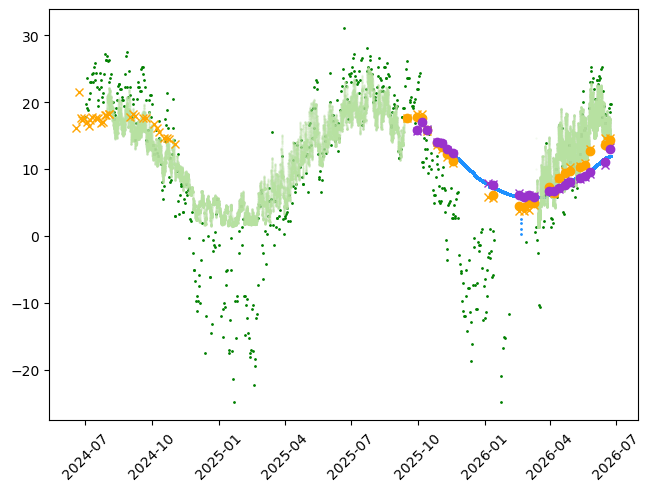

In [23]:
fig, ax = plt.subplots(layout='constrained')
plt.scatter(P2hobodfdate, P2filteredhobo, s = 1, color = "dodgerblue", label = "P2 continuous temperature data")
ax.plot(P2mandf.Date, P2mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime) and mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"]). 
ax.plot(P2mandf.Date, P2mandf.loc[:,"Temp bottom before"], 'x', color = "darkorchid", label = "manual temperature at bottom before pumping")
ax.plot(P2mandf.Date, P2mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(P2mandf.Date, P2mandf.loc[:,"Temp bottom after"], 'o', color = "darkorchid", label = "manual temperature at bottom after pumping")
plt.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], s = 1, color = "green", label = "air temperature")
ax.scatter(C2hobodfdate, C2filteredhobo, color = "xkcd:light grey green", alpha = 0.2, s = 0.2, label = "C2 continuous temperature data")
# ax.plot(C2hobodfdate, C2filteredhobo, color = "xkcd:light grey green", label = "C2 continuous temperature data")
plt.xticks(rotation=45)
# plt.ylim((-5, 20))
# plt.xlim((pd.to_datetime("2026-02-18"), pd.to_datetime("2026-02-20")))

# fig.legend(loc='outside upper right')
plt.show;

In [41]:
#dropping the 2024-06-18 thru 2024-11-01 data because it seems to have been measured incorrectly.
P2mandf = P2mandf.drop(np.arange(0, 29))
print(P2mandf.loc[:,"SPC top before"])

29    517
30    668
31    726
32    742
33    755
34    791
35    792
36    799
37    769
38    766
39    755
40    771
41    776
42    781
43    796
44    775
45    783
46    791
47    790
48    776
49    791
50    789
51    777
52    783
Name: SPC top before, dtype: str


In [37]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
P2filteredSPC = hampel(P2hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)

print(P2filteredSPC.filtered_data)

0          0.000000
1        908.718323
2        911.283997
3        910.612244
4        910.904907
            ...    
21499    844.328735
21500    844.336975
21501    844.336975
21502    844.105469
21503    844.328735
Length: 21504, dtype: float32


In [38]:

P2filteredSPCseries = pd.Series(P2filteredSPC.filtered_data, index = P2hobodf.index)

P2filteredSPC = P2filteredSPCseries[1:]              #I used the google AI overview for this line of code :/

In [43]:
P2hobodf

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
0,2025-11-11 14:41:12,17.708073,0.000000,0.000000,0.009297,0.000000
1,2025-11-11 14:56:12,12.854618,676.946960,908.718323,0.436320,440.015503
2,2025-11-11 15:11:12,13.005283,681.741577,911.283997,0.437839,443.132019
3,2025-11-11 15:26:12,13.032383,681.757202,910.612244,0.437547,443.142151
4,2025-11-11 15:41:12,13.029392,681.919128,910.904907,0.437689,443.247406
...,...,...,...,...,...,...
21499,2026-06-23 14:26:12,11.966251,613.228638,844.328735,0.402904,398.598602
21500,2026-06-23 14:41:12,11.966251,613.384949,844.543945,0.403010,398.700195
21501,2026-06-23 14:56:12,11.966251,613.234619,844.336975,0.402908,398.602478
21502,2026-06-23 15:11:12,11.966251,613.066467,844.105469,0.402793,398.493195


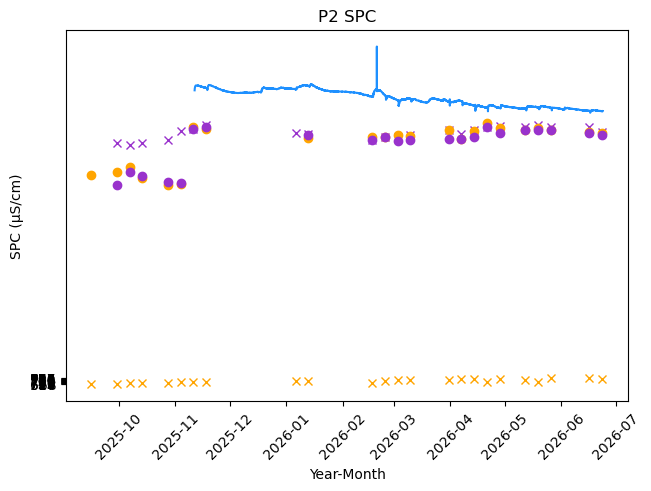

In [49]:

P2hobodate = P2hobodf["Date-Time"]
P2slicedhobodate = P2hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.plot(P2slicedhobodate, P2filteredSPC, color="dodgerblue", label = "HOBO continuous temperature")
ax.plot(P2mandf.Date, P2mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(P2mandf.Date, P2mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual SPC at bottom before pumping")
ax.plot(P2mandf.Date, P2mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(P2mandf.Date, P2mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P2 SPC")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])


plt.show()

In [12]:
hobodf = pd.read_csv("P2_current.csv")
mandf = pd.read_csv("P2ManualData.csv")
hobodate = pd.to_datetime(hobodf["Date-Time"])
slicedhobodate = hobodate[1:]
mandf["Date"] = pd.to_datetime(mandf["Date"])

In [13]:
hobodf

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
0,2025-11-11 14:41:12,17.708073,0.000000,0.000000,0.009297,0.000000
1,2025-11-11 14:56:12,12.854618,676.946960,908.718323,0.436320,440.015503
2,2025-11-11 15:11:12,13.005283,681.741577,911.283997,0.437839,443.132019
3,2025-11-11 15:26:12,13.032383,681.757202,910.612244,0.437547,443.142151
4,2025-11-11 15:41:12,13.029392,681.919128,910.904907,0.437689,443.247406
...,...,...,...,...,...,...
21499,2026-06-23 14:26:12,11.966251,613.228638,844.328735,0.402904,398.598602
21500,2026-06-23 14:41:12,11.966251,613.384949,844.543945,0.403010,398.700195
21501,2026-06-23 14:56:12,11.966251,613.234619,844.336975,0.402908,398.602478
21502,2026-06-23 15:11:12,11.966251,613.066467,844.105469,0.402793,398.493195


In [14]:
print(hobodf["Specific Conductivity"])

0          0.000000
1        908.718323
2        911.283997
3        910.612244
4        910.904907
            ...    
21499    844.328735
21500    844.543945
21501    844.336975
21502    844.105469
21503    844.328735
Name: Specific Conductivity, Length: 21504, dtype: float64


In [15]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
filteredhobo = hampel(hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)

print(filteredhobo.filtered_data)

0          0.000000
1        908.718323
2        911.283997
3        910.612244
4        910.904907
            ...    
21499    844.328735
21500    844.336975
21501    844.336975
21502    844.105469
21503    844.328735
Length: 21504, dtype: float32


In [16]:
#type(filteredhobo)
#type(hobodate)

#filteredhobo = filteredhobo.reshape(hobodate.shape)
filteredhoboseries = pd.Series(filteredhobo.filtered_data, index = hobodf.index)
#type(filteredhoboseries)
filteredhobo = filteredhoboseries[1:]              #I used the google AI overview for this line of code :/

In [17]:
print(mandf.loc[:,"SPC top before"])

0          
1       3.9
2       564
3       503
4       647
5     468.9
6       416
7       396
8     368.1
9       304
10      290
11    269.1
12    258.5
13    252.6
14    246.2
15      247
16    249.7
17    214.6
18    210.1
19    110.6
20      196
21    196.1
22    196.4
23    194.7
24    477.9
25    423.1
26    394.9
27    379.4
28    353.6
29      517
30      668
31      726
32      742
33      755
34      791
35      792
36      799
37      769
38      766
39      755
40      771
41      776
42      781
43      796
44      775
45      783
46      791
47      790
48      776
49      791
50      789
51      777
52      783
Name: SPC top before, dtype: str


In [18]:
mandf = mandf.drop(np.arange(0, 30))
print(mandf.loc[:,"SPC top before"])

30    668
31    726
32    742
33    755
34    791
35    792
36    799
37    769
38    766
39    755
40    771
41    776
42    781
43    796
44    775
45    783
46    791
47    790
48    776
49    791
50    789
51    777
52    783
Name: SPC top before, dtype: str


In [19]:
mandf

,Well,Date,Depth to water,Temp top before,Temp bottom before,SPC top before,SPC bottom before,Cond top before,Cond bottom before,Salinity top before,...,Recharge time,Temp top after,Temp bottom after,SPC top after,SPC bottom after,Cond top after,Cond bottom after,Salinity top after,Salinity bottom after,Notes
30,P2,2025-09-30,5.56,18.2,15.7,668,746.0,582.0,613.0,0.4,...,8:41.00,17.8,15.90,656.0,616.0,760.0,745.0,0.4,0.4,NaN
31,P2,2025-10-07,5.53,18.2,17.3,726,739.0,631.0,631.0,0.4,...,9.05.00,17.7,17.00,670.0,657.0,778.0,775.0,0.4,0.4,NaN
32,P2,2025-10-14,5.59,15.7,16.0,742,747.0,610.0,618.0,0.4,...,8:17.51,15.8,15.90,638.0,645.0,775.0,780.0,0.4,0.4,"Not at bottom, 6.5ft into well"
33,P2,2025-10-28,5.56,13.7,14.1,755,755.0,593.0,600.0,0.4,...,10:20.00,13.9,14.10,616.0,625.0,781.0,788.0,0.4,0.4,Not at bottom--At 7.1ft down from top of well
34,P2,2025-11-04,5.57,13.1,13.8,791,783.0,611.0,615.0,0.4,...,7:00.82,13.4,13.90,619.0,621.0,795.0,788.0,0.4,0.4,NaN
35,P2,2025-11-11,5.59,11.8,12.9,792,790.0,529.0,608.0,0.4,...,7:50.14,12.3,13.10,795.0,788.0,603.0,610.0,0.4,0.4,NaN
36,P2,2025-11-18,5.59,10.9,12.3,799,800.0,584.0,606.0,0.4,...,07:04.82,11.2,12.40,789.0,794.0,580.0,663.0,0.4,0.4,NaN
37,P2,2026-01-06,NaN,5.8,8.0,769,776.0,487.0,524.0,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,P2,2026-01-13,5.61,5.7,7.8,766,774.0,483.0,519.0,0.4,...,8:59.00,6.1,7.70,762.0,770.0,488.0,517.0,0.4,0.4,NaN
39,P2,2026-02-17,5.72,3.8,6.5,755,756.0,451.7,489.0,0.4,...,06:27.20,4.5,6.20,764.0,756.0,466.0,486.0,0.4,0.4,NaN


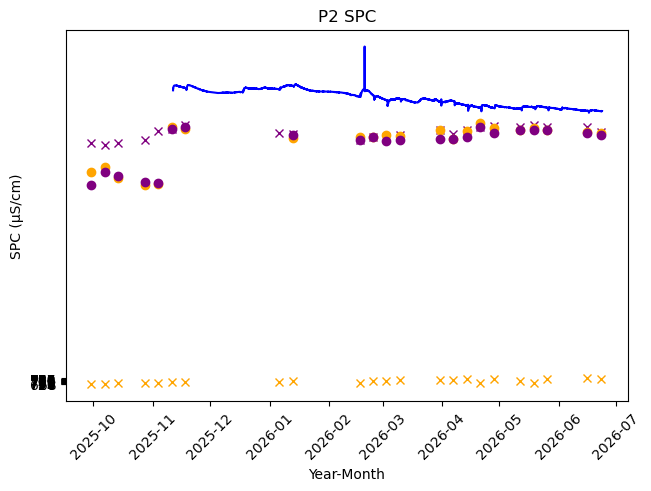

In [20]:
hobodf.columns = hobodf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  
fig, ax = plt.subplots(layout='constrained')
ax.plot(slicedhobodate, filteredhobo, color="blue", label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P2 SPC")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()